We check the code for simulation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

### Testing the different types of correlation functions

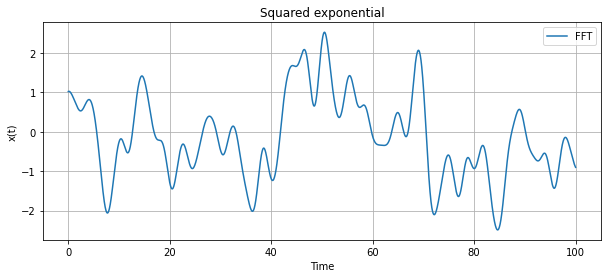

In [ ]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = utils.simulate_gaussian_process_fft(process.r_squared_exp, T, dt, tau=tau, sigma=sigma)
# t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_squared_exp, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
# plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Squared exponential')
plt.legend()
plt.grid(True)
plt.show()

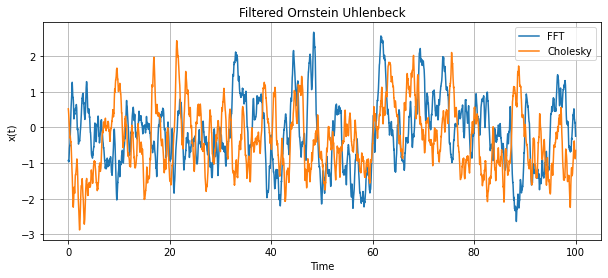

In [ ]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
tau_f = 0.1   # Correlation decay parameter
dt = 0.1 * min(tau_e, tau_f)   # Time discretization step
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = utils.simulate_gaussian_process_fft(process.r_filtered_OU, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)
t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_filtered_OU, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Filtered Ornstein Uhlenbeck')
plt.legend()
plt.grid(True)
plt.show()

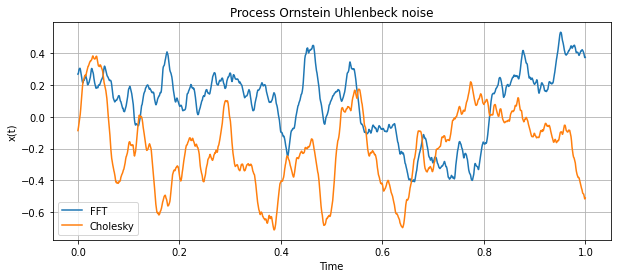

In [ ]:
# Set simulation parameters.
T = 1.0    # Total simulation time (e.g., 10 time units)
tau_e = 0.06   # Correlation decay parameter
tau_f = 0.005   # Correlation decay parameter
dt = 0.1 * min(tau_e, tau_f)   # Time discretization step
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = utils.simulate_gaussian_process_fft(process.r_OU_noise, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)
t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_OU_noise, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Process Ornstein Uhlenbeck noise')
plt.legend()
plt.grid(True)
plt.show()

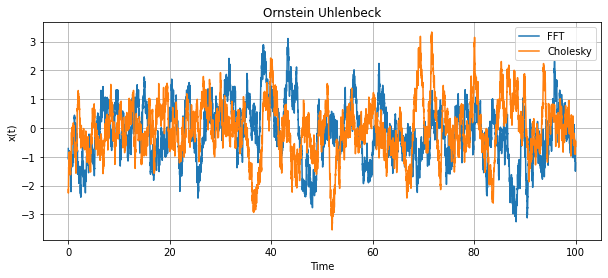

In [ ]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_e = 1.0   # Correlation decay parameter
dt = 0.01
sigma = 1.0 # Standard deviation (amplitude) of the process

# Generate a sample path of the Gaussian process.
# The additional parameters tau and sigma are passed after T and dt.
t, x = utils.simulate_gaussian_process_fft(process.r_OU, T, dt, sigma=sigma, tau=tau)
t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_OU, T, dt, sigma=sigma, tau=tau)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Ornstein Uhlenbeck')
plt.legend()
plt.grid(True)
plt.show()

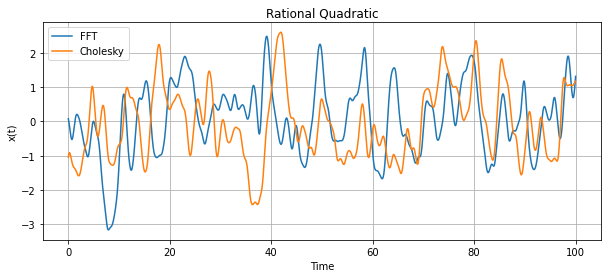

In [ ]:
# Set simulation parameters.
T = 100.0     # Total simulation time
dt = 0.01     # Time discretization step
tau = 1.0     # Length-scale parameter
sigma = 1.0   # Standard deviation of the process
alpha = 1.5   # Shape parameter of the rational quadratic function

# Generate a sample path of the Gaussian process.
t, x = utils.simulate_gaussian_process_fft(process.r_rational_quadratic, T, dt, tau=tau, sigma=sigma, alpha=alpha)
t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_rational_quadratic, T, dt, tau=tau, sigma=sigma, alpha=alpha)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Rational Quadratic')
plt.legend()
plt.grid(True)
plt.show()

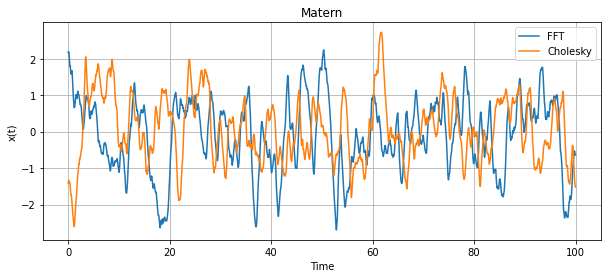

In [ ]:
# Set simulation parameters.
T = 100.0    # Total simulation time
dt = 0.01    # Time discretization step
tau = 1.0    # Length-scale parameter
sigma = 1.0  # Standard deviation of the process
nu = 1.5     # Smoothness parameter for the Matern function

# Generate a sample path of the Gaussian process.
t, x = utils.simulate_gaussian_process_fft(process.r_matern, T, dt, tau=tau, sigma=sigma, nu=nu)
t1, x1 = utils.simulate_gaussian_process_cholesky(process.r_matern, T, dt, tau=tau, sigma=sigma, nu=nu)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='FFT')
plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Matern')
plt.legend()
plt.grid(True)
plt.show()

### Testing the crossing times and number of crossings

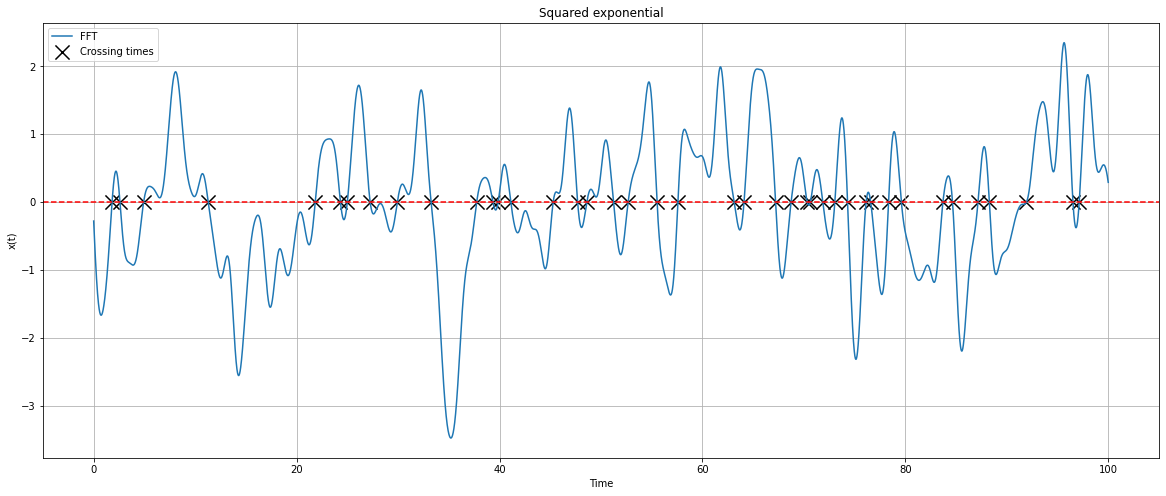

In [ ]:
# For a type of Gaussian process with a squared-exponential autocorrelation function
def r_squared_exp(t, tau, sigma):
    return sigma ** 2 * torch.exp(- (t/ tau) ** 2)

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

t, x = utils.simulate_gaussian_process_fft(r_squared_exp, T, dt, tau=tau, sigma=sigma)

threshold = 0.0
time, directions = utils.crossing_times(x, t=t, threshold=threshold)

# Plot the result.
plt.figure(figsize=(20, 8))
plt.plot(t, x, label='FFT')
# plot a linea t the threshold
plt.axhline(y=threshold, color='r', linestyle='--')
# plot scatter plot a t threshold and crossing times
plt.scatter(time, threshold * np.ones_like(time), color='black', marker='x', label='Crossing times', s=200)
# plt.plot(t1, x1, label='Cholesky')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Squared exponential')
plt.legend()
plt.grid(True)
plt.show()